Остановка на эпохе 28: E = 0.000842 <= 0.001

=== Результаты обучения ===
Финальный выход сети: 0.399158
Целевое значение:      0.400000
Итоговая ошибка:       0.000842
Число эпох:            28

Веса скрытого слоя (w1):
           j=0     j=1
i=0 (bias) -0.05217  0.05567
i=1 (x1)   -0.03483 -0.08368

Веса выходного слоя (w2):
bias (j=0):  0.83101
от скр. 1:  -0.07107
от скр. 2:  -0.08968

=== Таблица сходимости ===
Эпоха   Выход y     Ошибка E
---------------------------
   0   -0.03963    0.43963
   1    0.07370    0.32630
   2    0.15538    0.24462
   3    0.21408    0.18592
   4    0.25681    0.14319
   5    0.28847    0.11153
  10    0.36449    0.03551
  20    0.39565    0.00435
  28    0.39916    0.00084


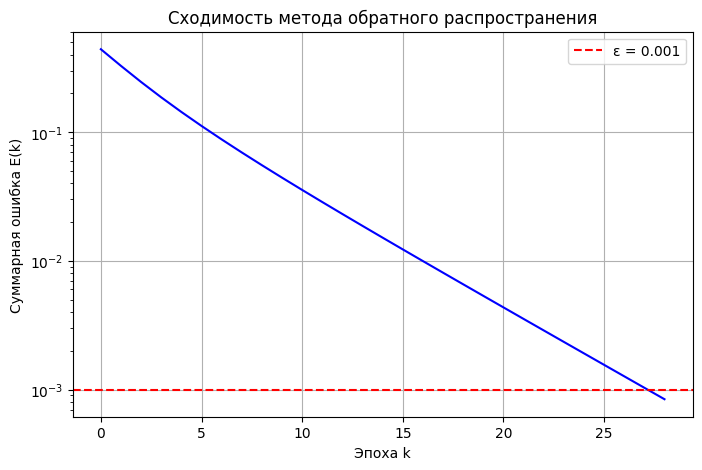

In [3]:

import numpy as np
import matplotlib.pyplot as plt

# Параметры варианта 23
# Архитектура: N=1 вход, J=2 скрытых, M=1 выход
# Вход: bias=1, сигнал=3
# Цель: масштабированное значение 0.4 (т.к. tanh выдает (-1,1))
x = [1.0, 3.0]          # x[0]=bias, x[1]=вход
t = 0.4                 # желаемый выход

eta = 1.0               # скорость обучения
eps = 1e-3              # требуемая ошибка
max_epochs = 1000

# Функция активации и её производная
def f(net):
    return (1 - np.exp(-net)) / (1 + np.exp(-net))

def df(net):
    out = f(net)
    return 0.5 * (1 - out**2)

# Инициализация весов (малые случайные)
np.random.seed(42)

# w1[вход][нейрон_скрытого]  размер 2x2
w1 = [[np.random.uniform(-0.1, 0.1) for _ in range(2)] for _ in range(2)]

# w2[нейрон_скрытого(включая bias)][выход]  размер 3x1, храним как список длины 3
w2 = [np.random.uniform(-0.1, 0.1) for _ in range(3)]


# Обучение
errors = []
outputs = []

for epoch in range(max_epochs + 1):
    # Прямой проход
    # Скрытый слой
    net1_j0 = w1[0][0] * x[0] + w1[1][0] * x[1]
    net1_j1 = w1[0][1] * x[0] + w1[1][1] * x[1]
    out1_j0 = f(net1_j0)
    out1_j1 = f(net1_j1)

    # Выходной слой (с учетом bias)
    net2 = w2[0] * 1.0 + w2[1] * out1_j0 + w2[2] * out1_j1
    y = f(net2)

    # Ошибка
    error = abs(t - y)
    errors.append(error)
    outputs.append(y)

    if error <= eps:
        print(f"Остановка на эпохе {epoch}: E = {error:.6f} <= {eps}")
        break

    # Обратный проход
    delta2 = df(net2) * (t - y)

    delta1_j0 = df(net1_j0) * w2[1] * delta2
    delta1_j1 = df(net1_j1) * w2[2] * delta2

    # Коррекция весов
    # Выходной слой
    w2[0] += eta * 1.0 * delta2
    w2[1] += eta * out1_j0 * delta2
    w2[2] += eta * out1_j1 * delta2

    # Скрытый слой
    w1[0][0] += eta * x[0] * delta1_j0
    w1[1][0] += eta * x[1] * delta1_j0
    w1[0][1] += eta * x[0] * delta1_j1
    w1[1][1] += eta * x[1] * delta1_j1

# Вывод результатов
print("\n=== Результаты обучения ===")
print(f"Финальный выход сети: {y:.6f}")
print(f"Целевое значение:      {t:.6f}")
print(f"Итоговая ошибка:       {error:.6f}")
print(f"Число эпох:            {len(errors)-1}")

print("\nВеса скрытого слоя (w1):")
print("           j=0     j=1")
print(f"i=0 (bias) {w1[0][0]:8.5f} {w1[0][1]:8.5f}")
print(f"i=1 (x1)   {w1[1][0]:8.5f} {w1[1][1]:8.5f}")

print("\nВеса выходного слоя (w2):")
print(f"bias (j=0): {w2[0]:8.5f}")
print(f"от скр. 1:  {w2[1]:8.5f}")
print(f"от скр. 2:  {w2[2]:8.5f}")


# Таблица первых и последних эпох
print("\n=== Таблица сходимости ===")
print("Эпоха   Выход y     Ошибка E")
print("---------------------------")
for k in [0, 1, 2, 3, 4, 5, 10, 20, 30, 40, 50, len(errors)-1]:
    if k < len(errors):
        print(f"{k:4d}   {outputs[k]:8.5f}   {errors[k]:8.5f}")


# График ошибки
plt.figure(figsize=(8,5))
plt.semilogy(range(len(errors)), errors, 'b-')
plt.xlabel("Эпоха k")
plt.ylabel("Суммарная ошибка E(k)")
plt.title("Сходимость метода обратного распространения")
plt.grid(True)
plt.axhline(y=eps, color='r', linestyle='--', label=f'ε = {eps}')
plt.legend()
plt.show()